Generated 5 ions
Hits on sample: 5


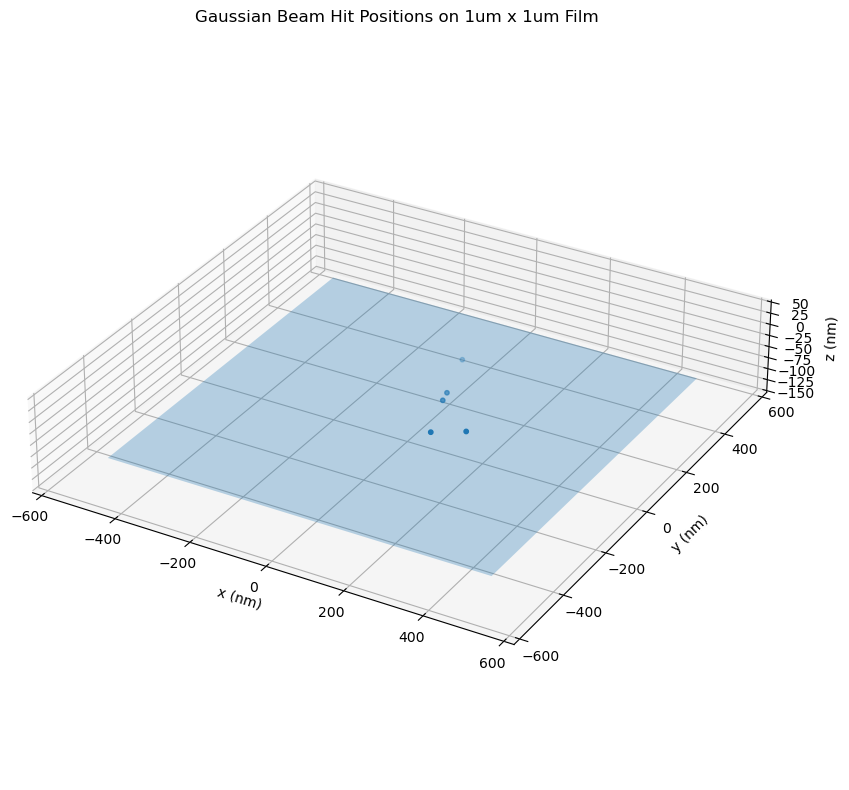

In [1]:
# test_gaussian_beam_hits.py

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from material import Material
from geometry import Geometry
from ion_source import GaussianIonBeam


# ============================================================
# INTERSECT RAY WITH TOP SURFACE OF FILM
# ============================================================

def intersect_top_surface(event, geometry):
    """
    Compute where ion intersects the top surface
    of the sample.

    Returns
    -------
    np.ndarray or None
        Intersection point in meters
    """

    pos = event.pos
    direction = event.vel / np.linalg.norm(event.vel)

    # top surface z
    z_top = geometry.location[2] - geometry.hz

    # avoid divide-by-zero
    if abs(direction[2]) < 1e-30:
        return None

    # ray parameter
    t = (z_top - pos[2]) / direction[2]

    # only forward intersections
    if t < 0:
        return None

    hit = pos + t * direction

    # ensure hit lies within sample x/y bounds
    if geometry.contains([hit[0], hit[1], z_top]):
        return hit

    return None


# ============================================================
# MAIN
# ============================================================

def main():

    # --------------------------------------------------------
    # MATERIAL
    # --------------------------------------------------------

    material = Material(name="NbN")

    # --------------------------------------------------------
    # GEOMETRY
    #
    # 1 um x 1 um x 200 nm
    # --------------------------------------------------------

    geom = Geometry(
        lx=1e-6,
        ly=1e-6,
        lz=200e-9,
        material=material
    )

    # --------------------------------------------------------
    # GAUSSIAN BEAM
    # --------------------------------------------------------

    beam = GaussianIonBeam(
        current_A=1e-12,
        energy_eV=30000.0,
        mass_amu=133.0,

        origin=(0.0, 0.0, -300e-9),

        sigma_x=100e-9,
        sigma_y=100e-9,

        angular_spread=0.01
    )

    # --------------------------------------------------------
    # SAMPLE IONS
    # --------------------------------------------------------

    events = beam.sample(t_end=1e-6)

    print(f"Generated {len(events)} ions")

    # limit for plotting
    events = events[:500]

    # --------------------------------------------------------
    # COMPUTE HITS
    # --------------------------------------------------------

    hits = []

    for event in events:

        hit = intersect_top_surface(event, geom)

        if hit is not None:
            hits.append(hit)

    hits = np.array(hits)

    print(f"Hits on sample: {len(hits)}")

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")

    # --------------------------------------------------------
    # DRAW TOP SURFACE ONLY
    # --------------------------------------------------------

    hx = geom.hx * 1e9
    hy = geom.hy * 1e9
    hz = geom.hz * 1e9

    verts = [[
        (-hx, -hy, -hz),
        ( hx, -hy, -hz),
        ( hx,  hy, -hz),
        (-hx,  hy, -hz),
    ]]

    surface = Poly3DCollection(
        verts,
        alpha=0.3
    )

    ax.add_collection3d(surface)

    # --------------------------------------------------------
    # PLOT HITS
    # --------------------------------------------------------

    if len(hits) > 0:

        hits_nm = hits * 1e9

        ax.scatter(
            hits_nm[:,0],
            hits_nm[:,1],
            hits_nm[:,2],
            s=10
        )

    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------

    ax.set_xlabel("x (nm)")
    ax.set_ylabel("y (nm)")
    ax.set_zlabel("z (nm)")

    ax.set_title("Gaussian Beam Hit Positions on 1um x 1um Film")

    ax.set_xlim(-600, 600)
    ax.set_ylim(-600, 600)
    ax.set_zlim(-150, 50)

    ax.set_box_aspect((1, 1, 0.2))

    plt.tight_layout()
    plt.show()

main()

In [2]:
import numpy as np

def srim_interacting_voxels(
    x0, y0,
    x_grid, y_grid, z_grid,
    Rp=10.18e3,        # nm (convert µm → nm)
    sigma_z=450,       # nm
    sigma_xy=550,      # nm
    threshold=1e-3
):
    """
    Returns list of voxels (i,j,k) that interact with a single ion.
    """

    X, Y, Z = np.meshgrid(x_grid, y_grid, z_grid, indexing="ij")

    # 3D Gaussian energy deposition kernel
    dx2 = (X - x0)**2
    dy2 = (Y - y0)**2
    dz2 = (Z - Rp)**2

    E = np.exp(-(dx2 + dy2) / (2 * sigma_xy**2)) \
        * np.exp(-dz2 / (2 * sigma_z**2))

    # normalize (optional but useful)
    E /= E.max()

    mask = E > threshold

    voxels = list(zip(
        X[mask].astype(int),
        Y[mask].astype(int),
        Z[mask].astype(int),
        E[mask]
    ))

    return voxels

In [ ]:
srim_interacting_voxels(